In [1]:
!unzip k-brazos.zip -d /content/


Archive:  k-brazos.zip
  inflating: /content/README.md      
  inflating: /content/bandit_experiment.ipynb  
   creating: /content/data/
 extracting: /content/data/README.md  
   creating: /content/docs/
 extracting: /content/docs/README.md  
 extracting: /content/main.ipynb     
  inflating: /content/requirements.txt  
   creating: /content/src/
  inflating: /content/src/README.md  
   creating: /content/src/algorithms/
  inflating: /content/src/algorithms/__init__.py  
  inflating: /content/src/algorithms/algorithm.py  
  inflating: /content/src/algorithms/epsilon_greedy.py  
  inflating: /content/src/algorithms/softmax.py  
   creating: /content/src/arms/
  inflating: /content/src/arms/__init__.py  
  inflating: /content/src/arms/arm.py  
  inflating: /content/src/arms/armnormal.py  
  inflating: /content/src/arms/bandit.py  
  inflating: /content/src/arms/armbernoulli.py  
  inflating: /content/src/arms/armbinomial.py  
   creating: /content/src/plotting/
  inflating: /content/src/

In [2]:
# main.ipynb
import numpy as np
import matplotlib.pyplot as plt
import sys
import os

# Asegurar que el path incluye src para las importaciones
sys.path.append(os.path.abspath("src"))

from algorithms.epsilon_greedy import EpsilonGreedy
from algorithms.softmax import Softmax
from arms.armnormal import ArmNormal
from arms.bandit import Bandit
from plotting.plotting import plot_average_rewards, plot_optimal_selections

# Configuración de reproducibilidad
SEED = 2026
np.random.seed(SEED)

## Función de experimentación

In [3]:
# -----------------------------------------------------------------------------
# 2. Definición del Motor de Experimentación
# -----------------------------------------------------------------------------
def run_experiment(bandit_generator, algorithms, n_steps=1000, n_runs=200):
    """
    Ejecuta el experimento de bandidos promediando sobre múltiples ejecuciones (runs).

    Args:
        bandit_generator (function): Función que devuelve una nueva instancia de Bandit.
        algorithms (list): Lista de instancias de algoritmos a probar.
        n_steps (int): Horizonte temporal (pasos por run).
        n_runs (int): Número de repeticiones independientes para suavizar la varianza.
    """
    n_algos = len(algorithms)

    # Matrices para almacenar resultados: [num_algoritmos, num_pasos]
    avg_rewards = np.zeros((n_algos, n_steps))
    optimal_selections = np.zeros((n_algos, n_steps))

    print(f"Iniciando simulación: {n_runs} ejecuciones de {n_steps} pasos...")

    for run in range(n_runs):
        # Generar un NUEVO entorno bandido para cada run (distintas medias reales)
        # Esto evalúa la capacidad del algoritmo de adaptarse a distintos problemas
        bandit = bandit_generator()
        optimal_arm = bandit.optimal_arm

        for i, algo in enumerate(algorithms):
            algo.reset() # Reiniciar memoria del agente

            for step in range(n_steps):
                # Ciclo clásico de RL:
                # 1. Agente selecciona acción
                arm_idx = algo.select_arm()

                # 2. Entorno devuelve recompensa
                reward = bandit.pull_arm(arm_idx)

                # 3. Agente aprende
                algo.update(arm_idx, reward)

                # 4. Registrar métricas
                avg_rewards[i, step] += reward
                if arm_idx == optimal_arm:
                    optimal_selections[i, step] += 1

    # Promediar y convertir conteos a porcentajes
    avg_rewards /= n_runs
    optimal_selections = (optimal_selections / n_runs) * 100

    return avg_rewards, optimal_selections



### Configuración del escenario

In [4]:
# -----------------------------------------------------------------------------
# 3. Configuración del Escenario (Normal)
# -----------------------------------------------------------------------------
def normal_bandit_generator():
    """Genera un bandido con 10 brazos y distribución Normal(0, 1) para las medias"""
    # Generamos 10 medias aleatorias extraídas de una normal estándar
    means = np.random.normal(0, 1, 10)
    # Creamos los brazos con sigma=1.0 (varianza unitaria)
    arms = [ArmNormal(mu=m, sigma=1.0) for m in means]
    return Bandit(arms)



In [5]:
# -----------------------------------------------------------------------------
# 4. Instanciación y Ejecución
# -----------------------------------------------------------------------------
# Comparamos distintas Temperaturas (tau) para analizar el trade-off exploración/explotación
algos = [
    Softmax(k=10, tau=0.01),   # Temperatura muy baja (casi greedy)
    Softmax(k=10, tau=0.1),    # Temperatura baja
    Softmax(k=10, tau=1.0),    # Temperatura moderada
    Softmax(k=10, tau=10.0),   # Temperatura alta (más exploración)
]

# Ejecutar experimento
rewards, optimal_percs = run_experiment(normal_bandit_generator, algos, n_steps=1000, n_runs=500)



Iniciando simulación: 500 ejecuciones de 1000 pasos...


In [6]:
optimal_percs

array([[ 9.6, 14.2, 16.4, ..., 36. , 36. , 36. ],
       [10.4, 15.8, 21.6, ..., 57. , 56.6, 56.6],
       [11.2, 14.4, 15.6, ..., 32.6, 35.2, 36.2],
       [10. , 10.4,  9.8, ...,  9.8, 11.4, 11.6]])

<Figure size 1200x600 with 0 Axes>

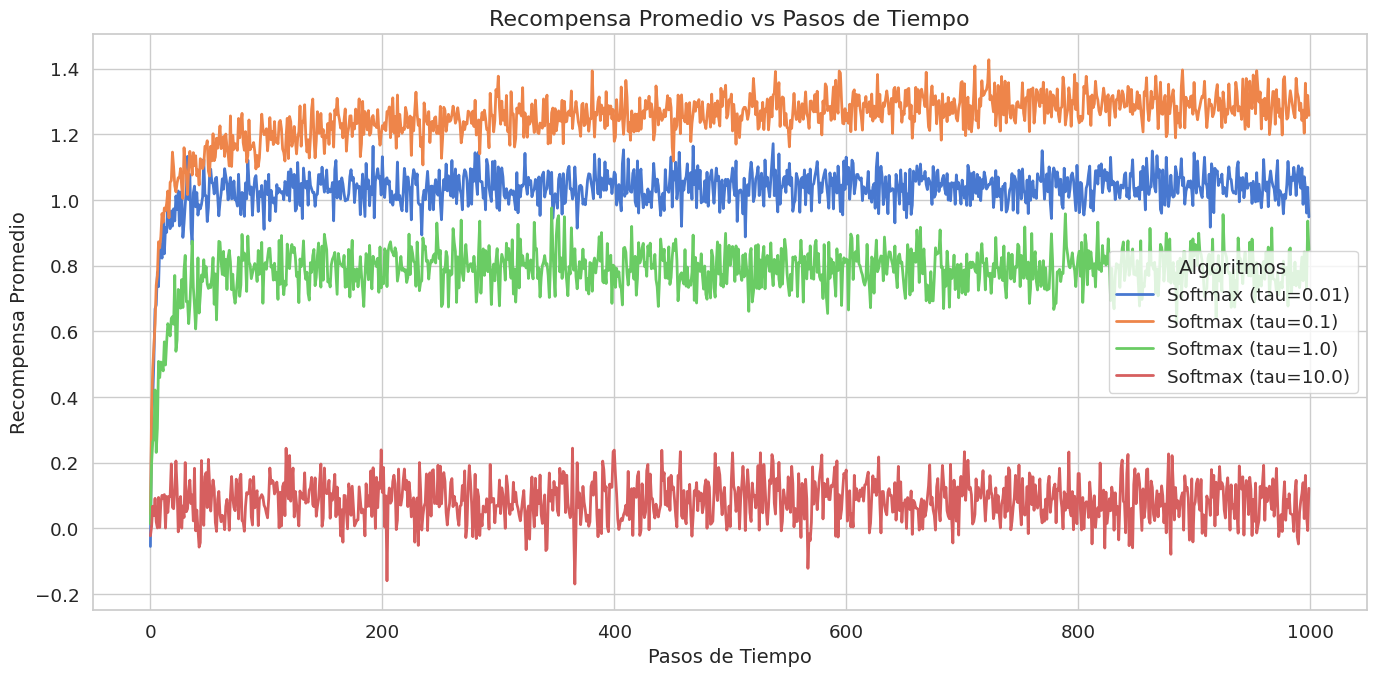

<Figure size 640x480 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

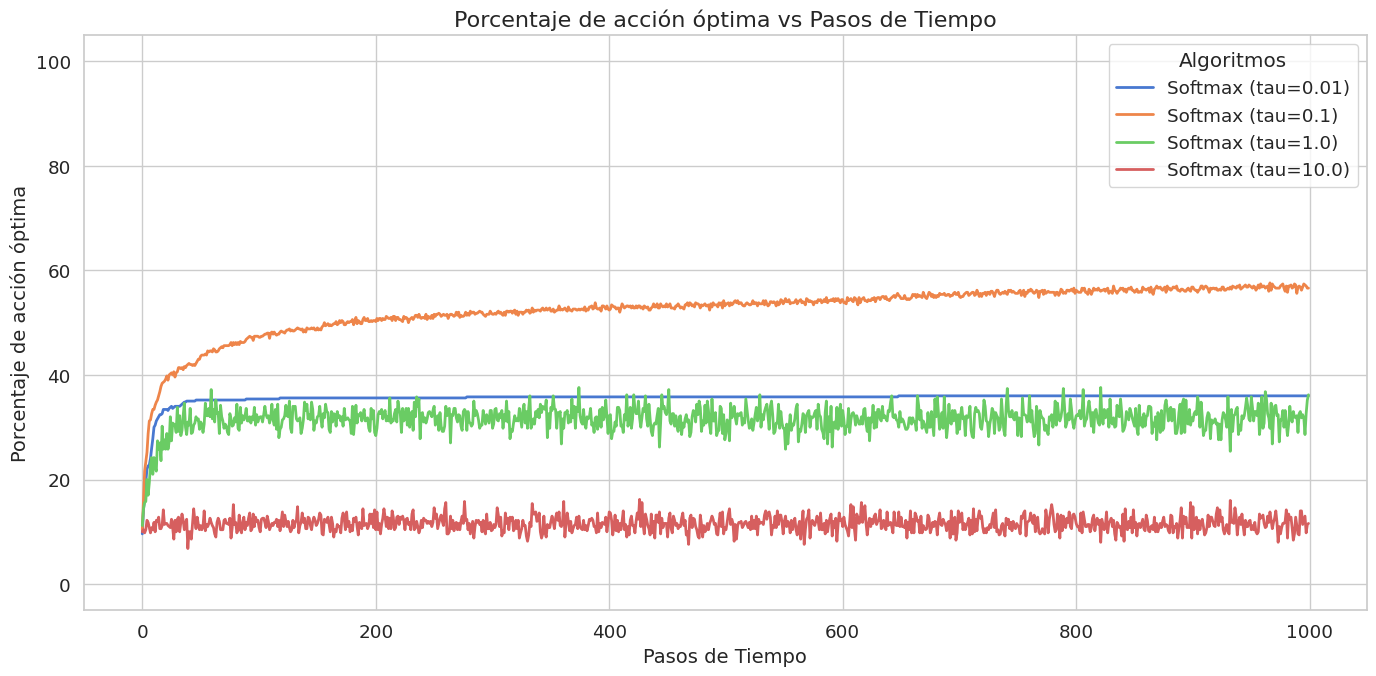

<Figure size 640x480 with 0 Axes>

In [9]:
# -----------------------------------------------------------------------------
# 5. Visualización de Resultados
# -----------------------------------------------------------------------------
# Gráfica 1: Recompensa Promedio
plt.figure(figsize=(12, 6))
plot_average_rewards(1000, rewards, algos)
plt.savefig("softmax_rewards.png")

# Gráfica 2: Selección Óptima
plt.figure(figsize=(12, 6))
plot_optimal_selections(1000, optimal_percs, algos)
plt.savefig("softmax_optimal_selections.png")